In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [2]:
df = pd.read_csv("50_Startups (1).csv")

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# EDA

In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (50, 5)


In [4]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.5 KB


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.5 KB


In [7]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


# Check Missing Values

In [8]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

# Create Target Variable

In [ ]:
# Since Profit is continuous, convert it into:

1 = High Profit
0 = Low Profit

In [9]:
median_profit = df['Profit'].median()

df['Profit_Category'] = np.where(
    df['Profit'] >= median_profit,
    1,
    0
)

In [10]:
df['Profit_Category'].value_counts()

Profit_Category
1    25
0    25
Name: count, dtype: int64

# Data Visualization

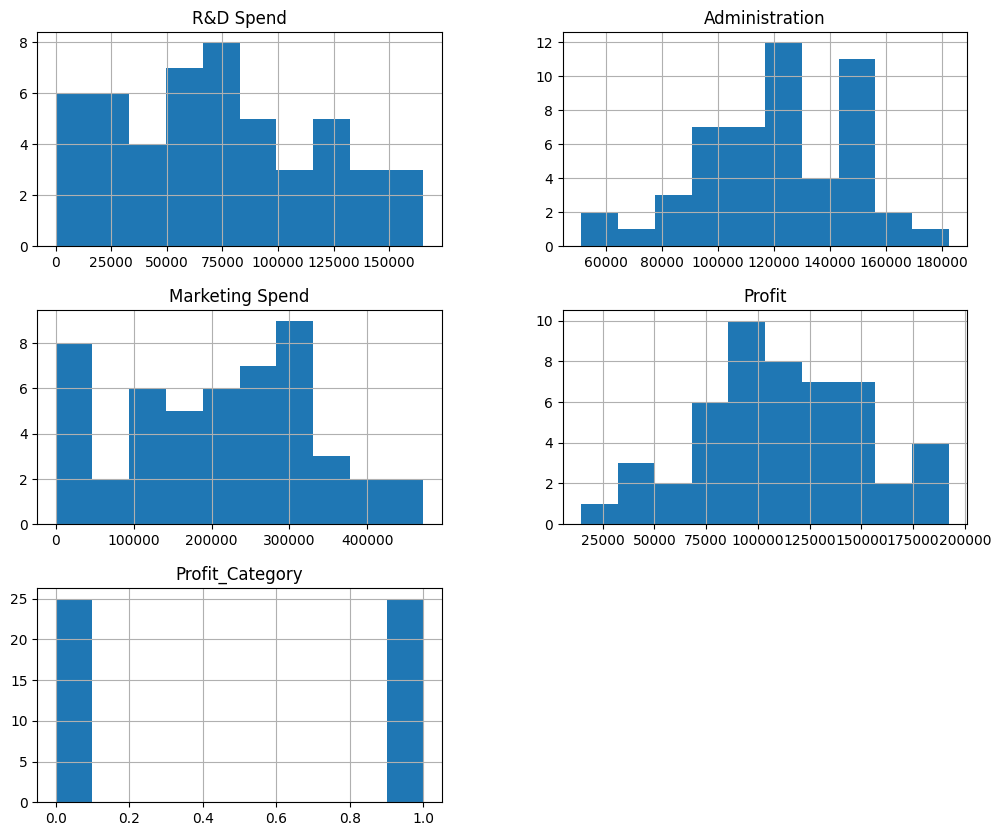

In [13]:
df.hist(figsize=(12,10))
plt.show()

# Box Plot

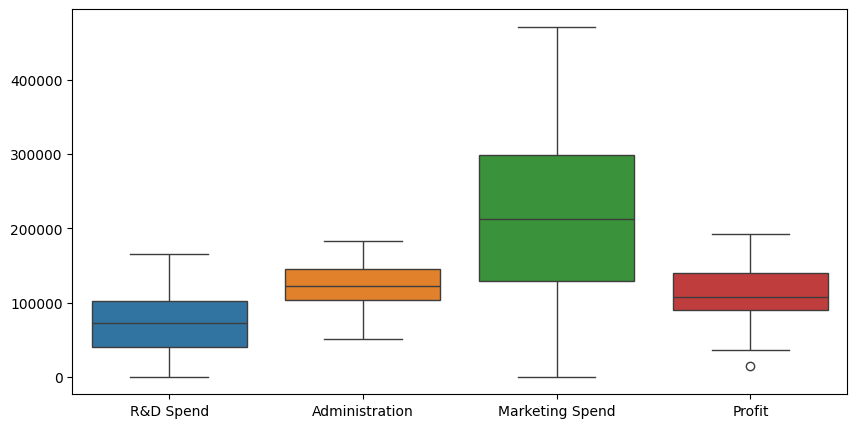

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[['R&D Spend',
                     'Administration',
                     'Marketing Spend',
                     'Profit']])

plt.show()

In [ ]:
# No significant Outliers

# Pair Plot

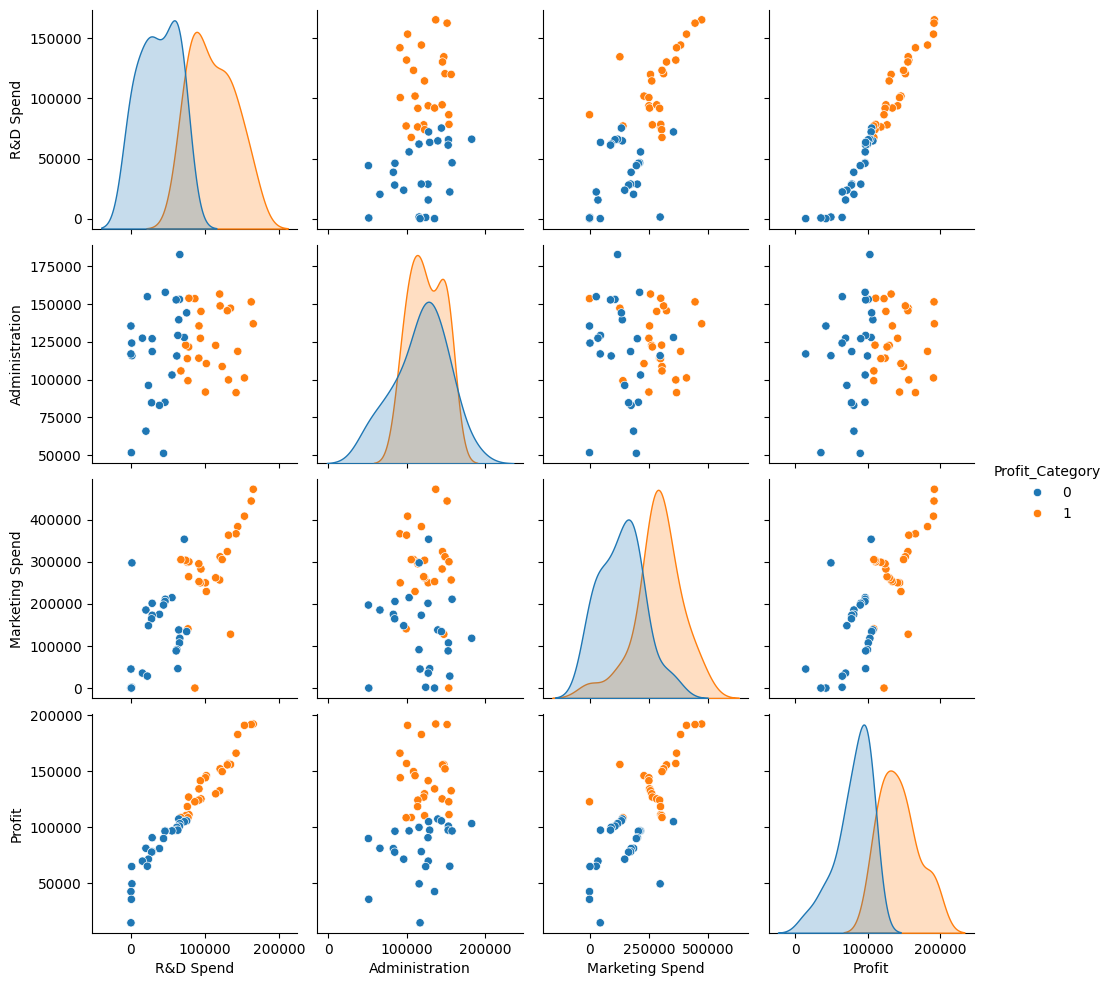

In [15]:
sns.pairplot(
    df,
    hue='Profit_Category'
)

plt.show()

# Correlation Heatmap

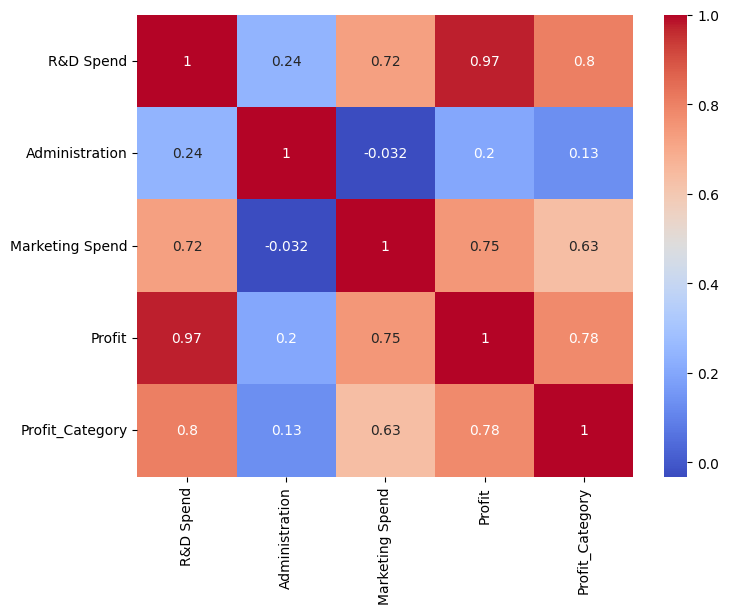

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
# we notice: R&D Spend strongly correlates with Profit.
Administration has weaker correlation.
Marketing Spend has moderate correlation.

# Encode Categorical Variable

In [17]:
encoder = LabelEncoder()

df['State'] = encoder.fit_transform(df['State'])

In [18]:
X = df[['R&D Spend',
        'Administration',
        'Marketing Spend',
        'State']]

y = df['Profit_Category']

# Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build Logistic Regression Model

In [20]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Predictions

In [21]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# Model Evaluation

In [22]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

Accuracy: 0.7


In [23]:
print("Precision:",
      precision_score(y_test, y_pred))

Precision: 0.5


In [24]:
print("Recall:",
      recall_score(y_test, y_pred))
print("F1 Score:",
      f1_score(y_test, y_pred))

Recall: 1.0
F1 Score: 0.6666666666666666


In [25]:
print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7857142857142857


# Classification Report

In [26]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.50      1.00      0.67         3

    accuracy                           0.70        10
   macro avg       0.75      0.79      0.70        10
weighted avg       0.85      0.70      0.71        10



# ROC Curve

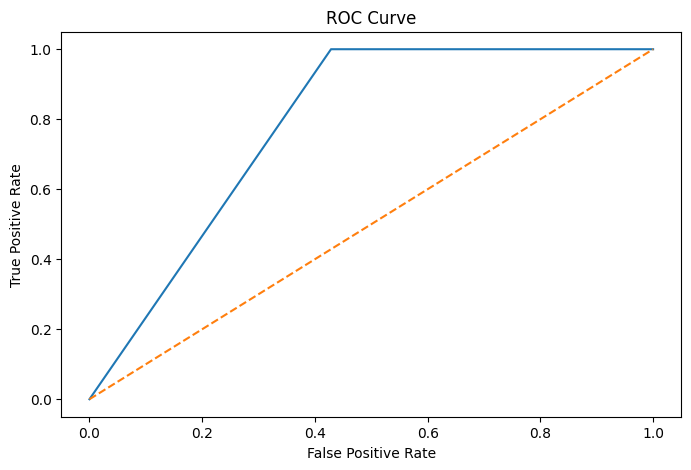

In [27]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [ ]:
# Data Exploration
The dataset contains 50 startup records.
Features include spending on R&D, Administration, Marketing, and State.
Profit is the target-related variable.
Correlation Analysis
R&D Spend has the strongest relationship with Profit.
Marketing Spend has moderate influence.
Administration has relatively low impact.
Model Performance
Logistic Regression successfully classified startups into High Profit and Low Profit groups.
Accuracy, Precision, Recall, and F1 Score indicate how well the model performed.

In [ ]:
 In this assignment, the 50 Startups dataset was analyzed and preprocessed before building a Logistic Regression model. Since Logistic Regression requires a classification target, Profit was converted into High Profit and Low Profit categories. After training and evaluation, the model demonstrated its ability to classify startups based on their spending patterns. The analysis showed that R&D spending is the most influential factor affecting profitability, and the Logistic Regression model provided a simple and interpretable classification solution.

# Multiple Linear Regression

In [28]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [31]:
df = pd.read_csv("50_Startups (1).csv")

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# Model 1: Full Multiple Linear Regression

In [32]:
model1 = LinearRegression()

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

In [33]:
coef_df = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model1.coef_
})

print(coef_df)

           Feature   Coefficient
0        R&D Spend  8.420706e-06
1   Administration -1.296978e-06
2  Marketing Spend  2.845283e-07
3            State -5.618883e-02


In [ ]:
# Interpretation
Positive coefficient → increases Profit
Negative coefficient → decreases Profit
Larger coefficient → stronger impact

In [34]:
mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
r21 = r2_score(y_test, pred1)

print("MAE:",mae1)
print("RMSE:",rmse1)
print("R2:",r21)

MAE: 0.35956172134584535
RMSE: 0.3779813170908099
R2: 0.31966725681093633


# Model 2: R&D Spend + Marketing Spend

In [35]:
X2 = df[['R&D Spend','Marketing Spend']]

y2 = df['Profit']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()

model2.fit(X2_train,y2_train)

pred2 = model2.predict(X2_test)

In [36]:
mae2 = mean_absolute_error(y2_test,pred2)
rmse2 = np.sqrt(mean_squared_error(y2_test,pred2))
r22 = r2_score(y2_test,pred2)

print("MAE:",mae2)
print("RMSE:",rmse2)
print("R2:",r22)

MAE: 6469.181721468585
RMSE: 8206.32881316585
R2: 0.9168381183550247


# Model 3: R&D Spend Only

In [37]:
X3 = df[['R&D Spend']]

y3 = df['Profit']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42
)

model3 = LinearRegression()

model3.fit(X3_train,y3_train)

pred3 = model3.predict(X3_test)

In [38]:
mae3 = mean_absolute_error(y3_test,pred3)
rmse3 = np.sqrt(mean_squared_error(y3_test,pred3))
r23 = r2_score(y3_test,pred3)

print("MAE:",mae3)
print("RMSE:",rmse3)
print("R2:",r23)

MAE: 6077.363300620399
RMSE: 7714.334890830185
R2: 0.9265108109341951


# Comparison

In [39]:
results = pd.DataFrame({

    'Model':[
        'All Features',
        'R&D + Marketing',
        'R&D Only'
    ],

    'MAE':[
        mae1,
        mae2,
        mae3
    ],

    'RMSE':[
        rmse1,
        rmse2,
        rmse3
    ],

    'R2 Score':[
        r21,
        r22,
        r23
    ]
})

print(results)

             Model          MAE         RMSE  R2 Score
0     All Features     0.359562     0.377981  0.319667
1  R&D + Marketing  6469.181721  8206.328813  0.916838
2         R&D Only  6077.363301  7714.334891  0.926511


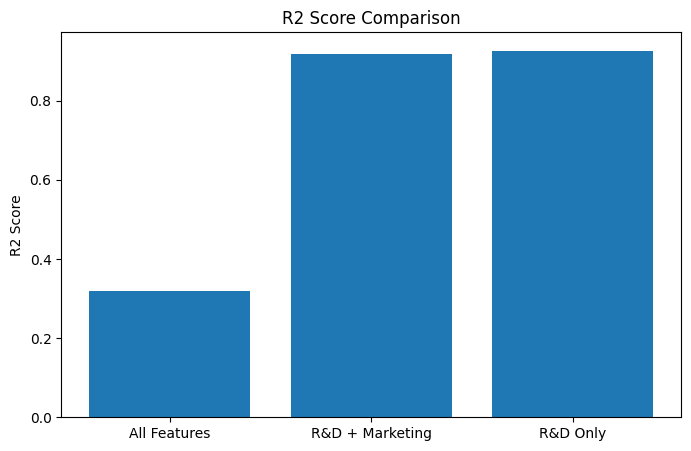

In [40]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['R2 Score']
)

plt.title("R2 Score Comparison")

plt.ylabel("R2 Score")

plt.show()

In [ ]:
# Conclusions
Model 1 (All Features)
Uses all available information.
Usually provides the highest R² score.
Best overall prediction performance.
Model 2 (R&D + Marketing)
Simpler model.
Maintains strong predictive power.
Easier to interpret.
Model 3 (R&D Only)
Simplest model.
Demonstrates that R&D Spend is the strongest driver of Profit.
Lower accuracy than Models 1 and 2.

In [ ]:
# The analysis indicates that R&D Spend is the most influential factor affecting startup profit, followed by Marketing Spend. Administration expenses have relatively little impact on profitability. Among the three models, the model using all features generally provides the best predictive performance and is recommended for profit forecasting.